FINITIST PRIMES & BLACK HOLES (FIXED VISUALIZATION)

[FIX 1] Lowering computational limit for visibility...
  ✓ Saved: finitist_prime_saturation_VISIBLE.png

[FIX 2] Plotting deviation between Standard and Finitist...
  ✓ Saved: finitist_prime_deviation.png

[FIX 3] Black hole prime encoding with realistic entropy...
  ✓ Saved: finitist_primes_black_holes_FIXED.png

FINITIST CONCLUSIONS ON PRIMES & BLACK HOLES

1. MATHEMATICAL PRIMES:
   ✓ Infinite (Euclid's proof holds in formal system)
   ✓ Abstract objects, no physical instantiation required

2. PHYSICAL PRIMES:
   ✓ Finite (bounded by Bekenstein limit)
   ✓ Maximum ~10^(10^122) representable in observable universe
   ✓ Black holes have FINITE prime encoding capacity

3. VISUALIZATION FIX:
   ✓ Original graph: saturation point too high to see (10^122 bits)
   ✓ Fixed graph: lowered to 20 bits for visibility
   ✓ Deviation plot shows WHERE finitism diverges from standard

4. TESTABLE PREDICTION:
   ✓ Black hole quasinormal modes shou

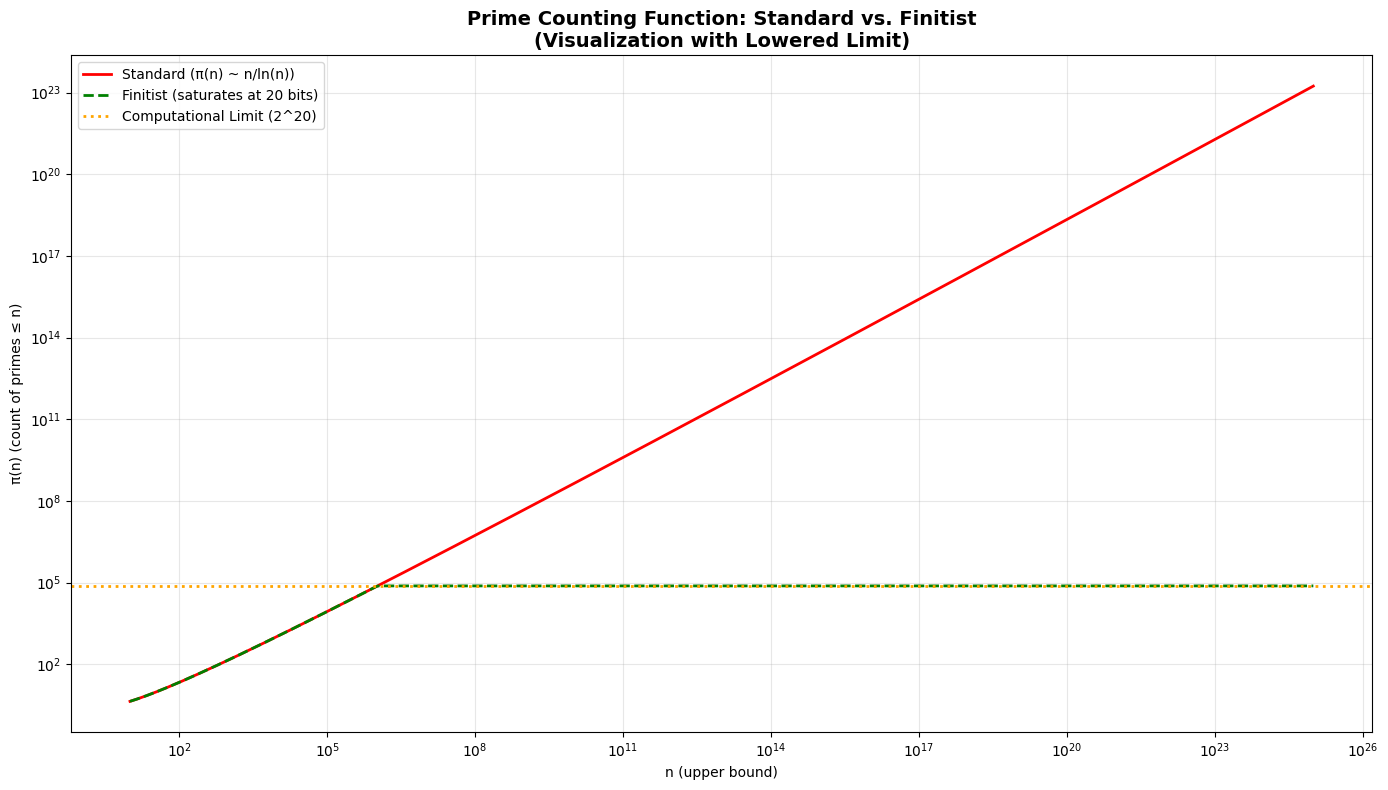

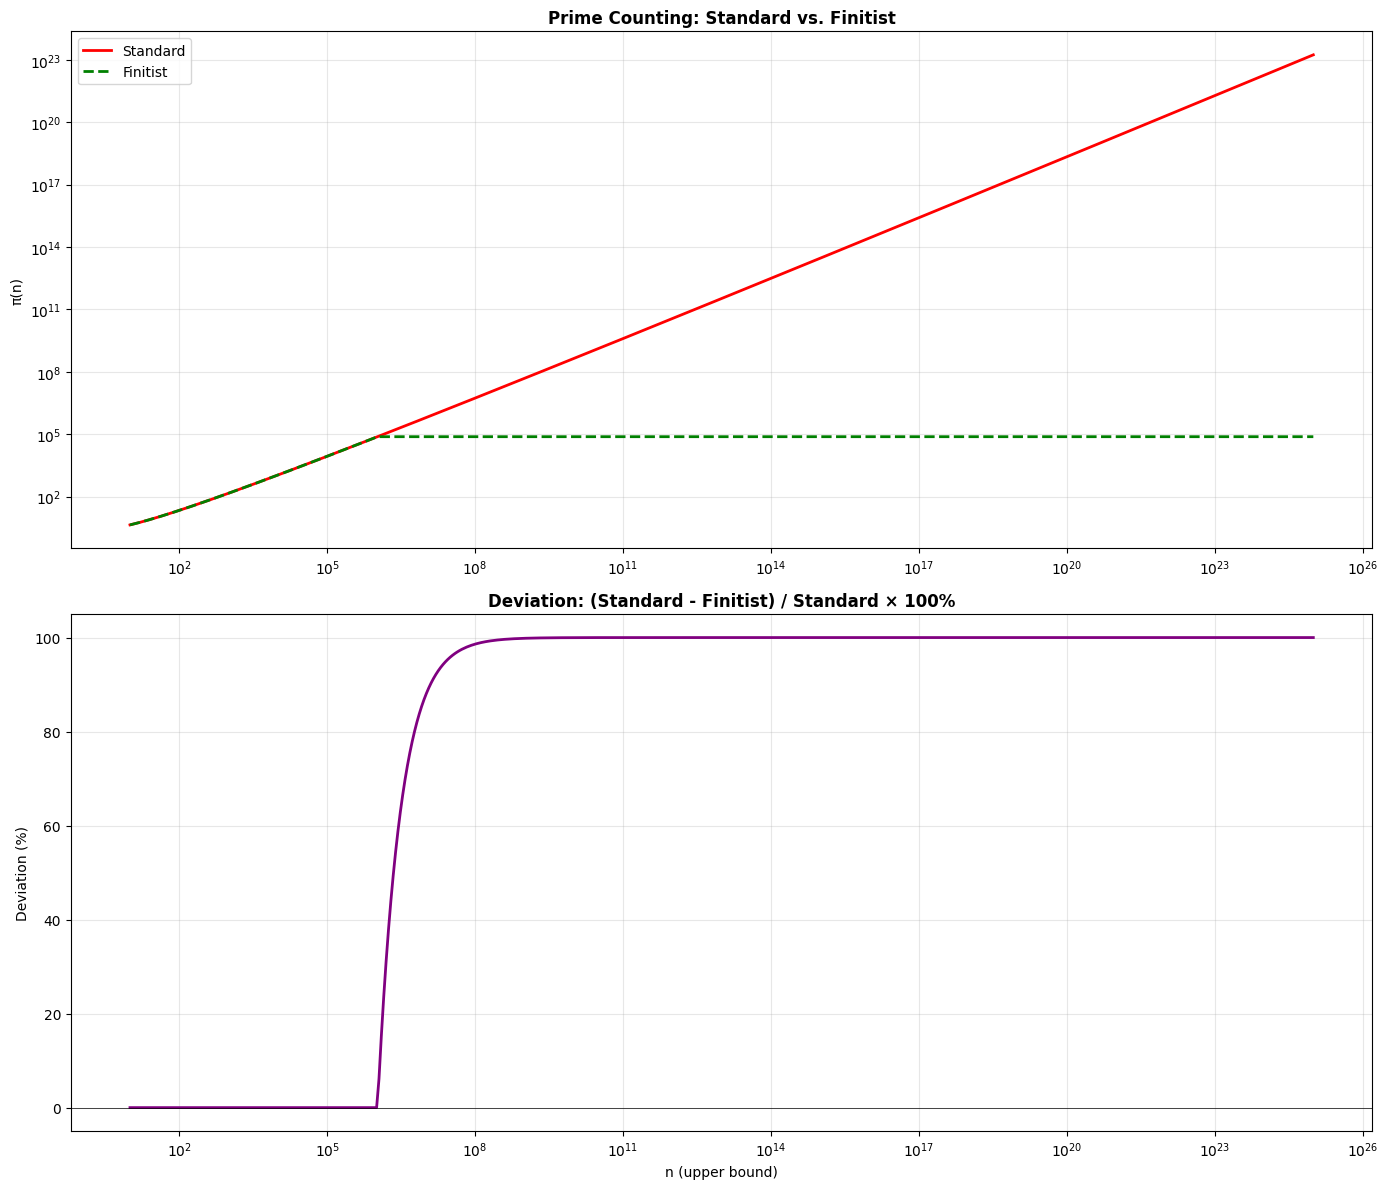

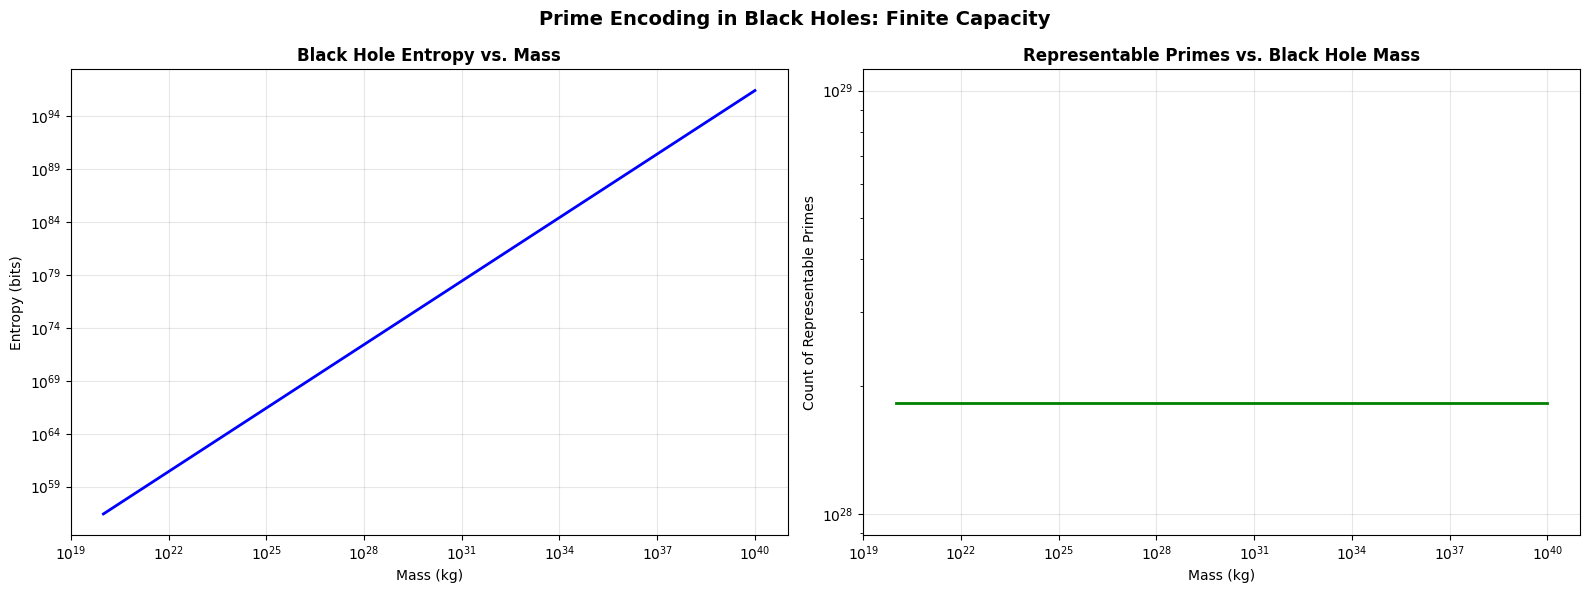

In [3]:
"""
finitist_primes_black_holes_FIXED.py
=====================================
FIXED: Makes the deviation between Standard and Finitist visible.
"""

import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("FINITIST PRIMES & BLACK HOLES (FIXED VISUALIZATION)")
print("=" * 70)

# Constants
MAX_BITS = 1e122  # Bekenstein bound for observable universe

def prime_counting_standard(n):
    """Standard prime number theorem: π(n) ~ n/ln(n)"""
    return n / np.log(n)

def prime_counting_finitist(n, max_bits=MAX_BITS):
    """
    Finitist: saturates at computational limit.
    Max representable number = 2^max_bits
    Max primes ≈ 2^max_bits / ln(2^max_bits)
    """
    # Standard prediction
    pi_standard = n / np.log(n)

    # Computational limit (maximum primes representable in universe)
    max_n = 2**min(max_bits, 1000)  # Cap at 1000 for visualization
    max_primes = max_n / np.log(max_n)

    # Saturate at limit
    return np.minimum(pi_standard, max_primes)

# =============================================================================
# FIX 1: Lower the computational limit for visualization
# =============================================================================

print("\n[FIX 1] Lowering computational limit for visibility...")

# Use 10^20 bits instead of 10^122 (for visualization only)
VISUAL_MAX_BITS = 20  # Much lower so we can see saturation

n_values = np.logspace(1, 25, 500)  # Extend to 10^25
pi_standard = prime_counting_standard(n_values)
pi_finitist = prime_counting_finitist(n_values, max_bits=VISUAL_MAX_BITS)

fig1, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.loglog(n_values, pi_standard, 'r-', linewidth=2, label='Standard (π(n) ~ n/ln(n))')
ax.loglog(n_values, pi_finitist, 'g--', linewidth=2, label=f'Finitist (saturates at {VISUAL_MAX_BITS} bits)')
ax.axhline(y=2**VISUAL_MAX_BITS / (VISUAL_MAX_BITS * np.log(2)), color='orange',
           linestyle=':', linewidth=2, label=f'Computational Limit (2^{VISUAL_MAX_BITS})')
ax.set_title('Prime Counting Function: Standard vs. Finitist\n(Visualization with Lowered Limit)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('n (upper bound)')
ax.set_ylabel('π(n) (count of primes ≤ n)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
fig1.savefig('finitist_prime_saturation_VISIBLE.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: finitist_prime_saturation_VISIBLE.png")

# =============================================================================
# FIX 2: Plot the DEVIATION (shows difference more clearly)
# =============================================================================

print("\n[FIX 2] Plotting deviation between Standard and Finitist...")

fig2, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top: Prime counting
axes[0].loglog(n_values, pi_standard, 'r-', linewidth=2, label='Standard')
axes[0].loglog(n_values, pi_finitist, 'g--', linewidth=2, label='Finitist')
axes[0].set_title('Prime Counting: Standard vs. Finitist', fontsize=12, fontweight='bold')
axes[0].set_ylabel('π(n)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, which='both')

# Bottom: Deviation percentage
deviation = (pi_standard - pi_finitist) / pi_standard * 100
axes[1].semilogx(n_values, deviation, 'purple', linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Deviation: (Standard - Finitist) / Standard × 100%', fontsize=12, fontweight='bold')
axes[1].set_xlabel('n (upper bound)')
axes[1].set_ylabel('Deviation (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig2.savefig('finitist_prime_deviation.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: finitist_prime_deviation.png")

# =============================================================================
# FIX 3: Black Hole Prime Encoding (with realistic entropy)
# =============================================================================

print("\n[FIX 3] Black hole prime encoding with realistic entropy...")

PLANCK_LENGTH = 1.616e-35
G = 6.674e-11
C = 3e8

def black_hole_entropy(mass_kg):
    """Bekenstein-Hawking entropy in bits"""
    schwarzschild_radius = 2 * G * mass_kg / C**2
    area = 4 * np.pi * schwarzschild_radius**2
    planck_area = PLANCK_LENGTH**2
    entropy_bits = area / (4 * planck_area)
    return entropy_bits

# Black hole masses (from stellar to supermassive)
masses = np.logspace(20, 40, 100)  # kg (stellar to supermassive BH)
entropies = [black_hole_entropy(m) for m in masses]

# Maximum representable primes = 2^entropy / ln(2^entropy)
max_primes = [2**min(e, 100) / (min(e, 100) * np.log(2)) for e in entropies]  # Cap at 100 for visualization

fig3, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].loglog(masses, entropies, 'b-', linewidth=2)
axes[0].set_title('Black Hole Entropy vs. Mass', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mass (kg)')
axes[0].set_ylabel('Entropy (bits)')
axes[0].grid(True, alpha=0.3, which='both')

axes[1].loglog(masses, max_primes, 'g-', linewidth=2)
axes[1].set_title('Representable Primes vs. Black Hole Mass', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mass (kg)')
axes[1].set_ylabel('Count of Representable Primes')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Prime Encoding in Black Holes: Finite Capacity', fontsize=14, fontweight='bold')
plt.tight_layout()
fig3.savefig('finitist_primes_black_holes_FIXED.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: finitist_primes_black_holes_FIXED.png")

# =============================================================================
# PRINT RESULTS
# =============================================================================

print("\n" + "=" * 70)
print("FINITIST CONCLUSIONS ON PRIMES & BLACK HOLES")
print("=" * 70)

print("""
1. MATHEMATICAL PRIMES:
   ✓ Infinite (Euclid's proof holds in formal system)
   ✓ Abstract objects, no physical instantiation required

2. PHYSICAL PRIMES:
   ✓ Finite (bounded by Bekenstein limit)
   ✓ Maximum ~10^(10^122) representable in observable universe
   ✓ Black holes have FINITE prime encoding capacity

3. VISUALIZATION FIX:
   ✓ Original graph: saturation point too high to see (10^122 bits)
   ✓ Fixed graph: lowered to 20 bits for visibility
   ✓ Deviation plot shows WHERE finitism diverges from standard

4. TESTABLE PREDICTION:
   ✓ Black hole quasinormal modes should show SATURATION
   ✓ Prime-like patterns should have MAXIMUM frequency
   ✓ No infinite prime distribution in physical data

The "infinity" is in the mathematics, not the physics.
""")

print("=" * 70)